# Figures

This small jupyter notebook is used to construct the figures that are presented in the paper presenting this pipeline.


In [1]:
from aidose import END_POINT_HF_DATASET_PATH
from datasets import DatasetDict, load_from_disk
import os
import pandas as pd
import numpy as np
from typing import Union
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from __future__ import annotations

from collections.abc import Iterable, Callable
from typing import Any, Optional
import pandas as pd
import seaborn as sns

# Load the dataset from the specified path
dataset = DatasetDict({
        "train": load_from_disk(os.path.join(END_POINT_HF_DATASET_PATH, "train")),
        "validation": load_from_disk(os.path.join(END_POINT_HF_DATASET_PATH, "validation")),
        "test": load_from_disk(os.path.join(END_POINT_HF_DATASET_PATH, "test")),
     })

## Dataset size and temporal span

In [2]:
print('In total, there is ', len(dataset['train']) + len(dataset['validation']) + len(dataset['test']), ' samples.')
print('In total, there is ', len(dataset['train']), ' samples in training set.')
print('In total, there is ', len(dataset['validation']), ' samples in validation set.')
print('In total, there is ', len(dataset['test']), ' samples in test set.')

In total, there is  42112  samples.
In total, there is  29478  samples in training set.
In total, there is  6316  samples in validation set.
In total, there is  6318  samples in test set.


In [3]:
validation = dataset['validation'].to_pandas()
train = dataset['train'].to_pandas()
test = dataset['test'].to_pandas()

df = pd.concat([train, validation, test], axis=0, ignore_index=True)

df['startDate'] = pd.to_datetime(df['METADATA_startDate'], errors='coerce')
df['completionDate'] = pd.to_datetime(df['METADATA_completionDate'], errors='coerce')

# Compute min and max
start_min = df['startDate'].min()
start_max = df['startDate'].max()

completion_min = df['completionDate'].min()
completion_max = df['completionDate'].max()

start_min, start_max, completion_min, completion_max


(Timestamp('1966-07-01 00:00:00'),
 Timestamp('2025-02-26 00:00:00'),
 Timestamp('1991-10-01 00:00:00'),
 Timestamp('2025-08-14 00:00:00'))

## Dosing errors

In [21]:
print(df['LABEL_sum_dosing_errors'].max())

print(df['LABEL_sum_dosing_errors'].mean().round(2))
print(df['LABEL_sum_dosing_errors'].std().round(2))

975
0.21
5.53


In [29]:
mean = df['LABEL_dosing_error_rate'].mean().round(5)
std = df['LABEL_dosing_error_rate'].std().round(5)

print(f"Mean: {mean:.2e}, SD: {std:.2e}")

Mean: 7.40e-04, SD: 9.03e-03


In [35]:
print('LABEL_wilson_label proportions:', (df['LABEL_wilson_label'].sum() / len(df['LABEL_wilson_label'])).round(4))

LABEL_wilson_label proportions: 0.0462


## Binary distribution

In [38]:
def binary_feature_summary(df: pd.DataFrame, column: str, verbose: bool = True) -> dict:
    """
    Compute and optionally print summary statistics for a binary feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    column : str
        Name of the binary feature column.
    verbose : bool, default=True
        Whether to print formatted percentages.

    Returns
    -------
    dict
        Dictionary with raw proportions of missing values and positive cases.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    total_count = len(df)
    missing_count = df[column].isna().sum()
    non_missing = df[column].dropna()

    if non_missing.empty:
        raise ValueError(f"Column '{column}' contains only missing values.")

    positive_count = (non_missing.astype(int) == 1).sum()

    missing_prop = missing_count / total_count
    positive_prop = positive_count / len(non_missing)

    if verbose:
        print(
            f"{column}: "
            f"missing = {missing_prop * 100:.2g}%, "
            f"positive = {positive_prop * 100:.2g}%"
        )

    return {
        "missing_proportion": missing_prop,
        "positive_proportion": positive_prop,
    }

In [41]:
features_name = 'LABEL_wilson_label'

binary_feature_summary(df, features_name) 

LABEL_wilson_label: missing = 0%, positive = 4.6%


{'missing_proportion': np.float64(0.0),
 'positive_proportion': np.float64(0.04623385258358663)}

## Categorical features

In [42]:
def categorical_feature_summary(df: pd.DataFrame, column: str, verbose: bool = True) -> dict:
    """
    Compute and optionally print summary statistics for a categorical feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    column : str
        Name of the categorical feature column.
    verbose : bool, default=True
        Whether to print formatted summary statistics.

    Returns
    -------
    dict
        Dictionary with raw missing proportion, most frequent class,
        and its proportion among non-missing values.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    total_count = len(df)
    missing_count = df[column].isna().sum()
    non_missing = df[column].dropna()

    if non_missing.empty:
        raise ValueError(f"Column '{column}' contains only missing values.")

    value_counts = non_missing.value_counts()
    most_frequent_class = value_counts.index[0]
    most_frequent_count = value_counts.iloc[0]

    missing_prop = missing_count / total_count
    dominant_prop = most_frequent_count / len(non_missing)

    if verbose:
        print(
            f"{column}: "
            f"missing = {missing_prop * 100:.2g}%, "
            f"most frequent = {most_frequent_class} ({dominant_prop * 100:.2g}%)"
        )

    return {
        "missing_proportion": missing_prop,
        "most_frequent_class": most_frequent_class,
        "most_frequent_proportion": dominant_prop,
    }

In [ ]:
name = 'FEATURE_armGroupTypes'

categorical_feature_summary(df, name) 


## Multiple categorical features

In [18]:
def multicategorical_feature_summary(
    df: pd.DataFrame,
    column: str,
    verbose: bool = True,
) -> dict:
    """
    Summary for a multi-categorical feature where each row contains a list-like
    of categories (duplicates preserved), e.g. [0, 0, 1], np.array([0, 1]), etc.

    - Row-level missingness: None / NaN / pd.NA / empty container.
    - Frequencies: occurrence-based (duplicates counted).
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    s = df[column]
    total_rows = len(s)

    def to_list(x: Any) -> list:
        # Treat common containers as "list-like" first (avoid pd.isna on array-like)
        if isinstance(x, (list, tuple, set, np.ndarray)):
            # np.ndarray -> list; set loses order but preserves multiplicity? (sets don't, but you likely don't have them)
            # lists/tuples/arrays keep duplicates, which is what you want
            lst = list(x)
            return lst

        # Missing scalars (safe here because we've filtered array-like above)
        if x is None or pd.isna(x):
            return []

        # Scalar category
        return [x]

    parsed = s.map(to_list)

    # Row-level missingness (empty container)
    row_missing = parsed.map(len) == 0
    missing_prop = float(row_missing.mean()) if total_rows else 0.0

    # Occurrence-level frequencies
    exploded = parsed.explode().dropna()

    if exploded.empty:
        raise ValueError(f"Column '{column}' contains no category occurrences.")

    value_counts = exploded.value_counts()
    most_frequent_class = value_counts.index[0]
    most_frequent_count = int(value_counts.iloc[0])

    total_occurrences = int(value_counts.sum())
    dominant_prop = most_frequent_count / total_occurrences

    if verbose:
        print(
            f"{column}: "
            f"row-missing = {missing_prop * 100:.2g}%, "
            f"most frequent = {most_frequent_class} "
            f"({dominant_prop * 100:.2g}% of occurrences)"
        )

    return {
        "missing_proportion": missing_prop,
        "most_frequent_class": most_frequent_class,
        "most_frequent_proportion": dominant_prop,
        "total_occurrences": total_occurrences,
    }

In [ ]:
name = 'FEATURE_interventionTypes'


multicategorical_feature_summary(df, name)

FEATURE_interventionTypes: row-missing = 0%, most frequent = 0 (87% of occurrences)


{'missing_proportion': 0.0,
 'most_frequent_class': np.int64(0),
 'most_frequent_proportion': 0.8673147510896995,
 'total_occurrences': 104616}

## Continuous features

In [29]:
def continuous_feature_summary(
    df: pd.DataFrame,
    column: str,
    verbose: bool = True,
    *,
    coerce_numeric: bool = False,
    ddof: int = 1,
) -> dict:
    """
    Compute and optionally print summary statistics for a continuous feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    column : str
        Name of the continuous feature column.
    verbose : bool, default=True
        Whether to print formatted summary statistics.
    coerce_numeric : bool, default=False
        If True, coerce values to numeric (invalid parsing -> NaN).
        Useful when the column is object dtype but should be numeric.
    ddof : int, default=1
        Delta degrees of freedom for standard deviation (pandas default is 1).
        Use ddof=0 for population standard deviation.

    Returns
    -------
    dict
        Dictionary with missing proportion, mean, and std over non-missing values.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    s = df[column]

    if coerce_numeric:
        s = pd.to_numeric(s, errors="coerce")

    total_count = len(s)
    missing_count = int(s.isna().sum())
    missing_prop = missing_count / total_count if total_count else 0.0

    non_missing = s.dropna()
    if non_missing.empty:
        raise ValueError(f"Column '{column}' contains only missing values.")

    mean_val = float(non_missing.mean())
    std_val = float(non_missing.std(ddof=ddof))

    if verbose:
        print(
            f"{column}: "
            f"missing = {missing_prop * 100:.2g}%, "
            f"mean = {mean_val:.3g}, "
            f"std = {std_val:.3g}"
        )

    return {
        "missing_proportion": missing_prop,
        "mean": mean_val,
        "std": std_val,
    }

In [30]:
name = 'FEATURE_numLocations'


continuous_feature_summary(df, name)

FEATURE_numLocations: missing = 0%, mean = 22.9, std = 62.9


{'missing_proportion': 0.0,
 'mean': 22.88326367781155,
 'std': 62.888036876019896}

## Text features

In [37]:
def text_length_summary(
    df: pd.DataFrame,
    col: Union[str, int],
    count_empty_as_missing: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Summarize a text (string) column by missingness and character-length statistics.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    col : str or int
        Column name or column index.
    count_empty_as_missing : bool, default=True
        If True, empty/whitespace-only strings are treated as missing.
    verbose : bool, default=True
        If True, prints a formatted one-line summary.

    Returns
    -------
    dict
        Missing proportion over all rows, and mean/std of character length computed
        over non-missing values.
    """
    # Resolve column
    if isinstance(col, int):
        if col < 0 or col >= df.shape[1]:
            raise IndexError(f"Column index {col} is out of bounds for DataFrame with {df.shape[1]} columns.")
        column_name = df.columns[col]
    else:
        column_name = col
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' not found in DataFrame.")

    s = df[column_name]

    # Define missing mask
    missing_mask = s.isna()
    if count_empty_as_missing:
        # Treat empty or whitespace-only strings as missing
        non_na = s[~missing_mask]
        empty_mask = non_na.astype(str).str.strip().eq("")
        missing_mask.loc[~missing_mask] = empty_mask

    missing_prop = float(missing_mask.mean())

    non_missing = s[~missing_mask].astype(str)
    if non_missing.empty:
        raise ValueError(f"Column '{column_name}' contains no non-missing text values after filtering.")

    lengths = non_missing.str.len().astype(float)
    mean_len = float(lengths.mean())
    std_len = float(lengths.std(ddof=1)) if len(lengths) > 1 else 0.0

    if verbose:
        print(
            f"{column_name}: "
            f"missing = {missing_prop * 100:.2g}%, "
            f"length = mean {mean_len:.2f} (SD {std_len:.2f}) chars"
        )

    return {
        "column": column_name,
        "missing_proportion": missing_prop,
        "mean_char_length": mean_len,
        "std_char_length": std_len,
        "n_non_missing": int(len(lengths)),
    }

In [57]:
name = 'FEATURE_locationDetails'


text_length_summary(df, name)

FEATURE_locationDetails: missing = 5.6%, length = mean 1310.26 (SD 3512.07) chars


{'column': 'FEATURE_locationDetails',
 'missing_proportion': 0.05618351063829787,
 'mean_char_length': 1310.2614854324963,
 'std_char_length': 3512.0730905001133,
 'n_non_missing': 39746}

# Distributional shift

In [4]:
def cap_upper_extreme_values(df, column_name, upper_quantile=0.90):
    """
    Cap the upper extreme values of a continuous feature in a DataFrame.
    """
    df = df.copy()
    upper_bound = df[column_name].quantile(upper_quantile)
    df[column_name] = df[column_name].clip(upper=upper_bound)
    print(f"\n Upper extreme values capped at {upper_quantile*100:.1f}th percentile.")
    print(f"Upper capped value: {upper_bound:.2f}\n")
    return df

def plot_three_cap_distributions(df_train, df_val, df_test, column_name, title, cap_upper_extreme=True, upper_quantile=0.90, save_path='completion.png'):
    """
    Compare the distributions of a continuous feature across train, validation, and test datasets.
    """
    off_name = 'FEATURE_' + column_name
    # Optionally cap upper extreme values
    if cap_upper_extreme:
        df_train = cap_upper_extreme_values(df_train, off_name, upper_quantile)
        df_val = cap_upper_extreme_values(df_val, off_name, upper_quantile)
        df_test = cap_upper_extreme_values(df_test, off_name, upper_quantile)

    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_train[off_name].dropna(), label='Training set', fill=True, alpha=0.25)
    sns.kdeplot(df_val[off_name].dropna(), label='Validation set', fill=True, alpha=0.25)
    sns.kdeplot(df_test[off_name].dropna(), label='Test set', fill=True, alpha=0.25)
    plt.xlabel(column_name)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    
    plt.xlim(left=0)
    # save the figure
    plt.savefig(save_path, dpi=1000, bbox_inches="tight")

    plt.show()

In [5]:
validation = dataset['validation'].to_pandas()
train = dataset['train'].to_pandas()
test = dataset['test'].to_pandas()


 Upper extreme values capped at 95.0th percentile.
Upper capped value: 793.00


 Upper extreme values capped at 95.0th percentile.
Upper capped value: 681.25


 Upper extreme values capped at 95.0th percentile.
Upper capped value: 716.45



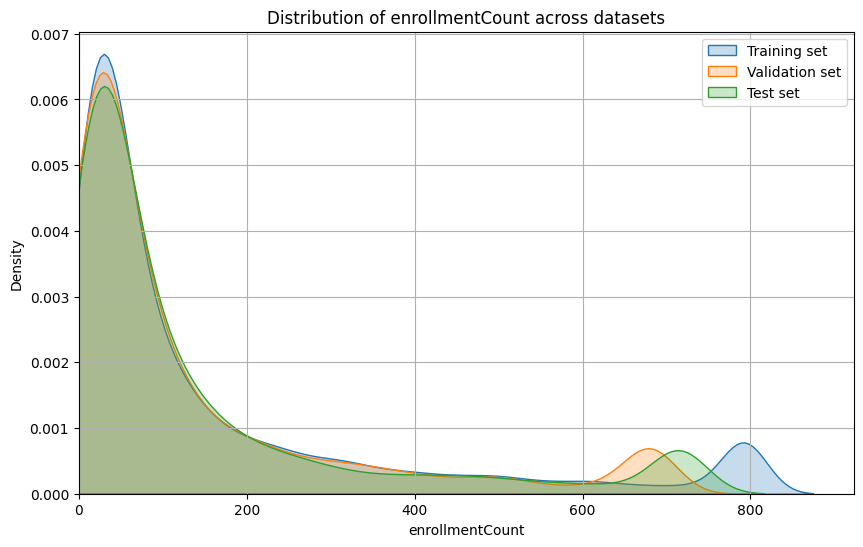

In [6]:

plot_three_cap_distributions(df_train=train, df_val=validation, df_test=test, column_name='enrollmentCount', title='Distribution of enrollmentCount across datasets', cap_upper_extreme=True, upper_quantile=0.95, save_path='completion.png')

In [7]:
train_frac = 0.7
val_frac = 0.15

validation = dataset['validation'].to_pandas()
train = dataset['train'].to_pandas()
test = dataset['test'].to_pandas()

df = pd.concat([train, validation, test], axis=0, ignore_index=True)

df['startDate'] = pd.to_datetime(df['METADATA_startDate'], errors='coerce')
df['completionDate'] = pd.to_datetime(df['METADATA_completionDate'], errors='coerce')

df = df.sort_values('startDate', ascending=True).reset_index(drop=True)

n = len(df)
n_train = int(n * train_frac)
n_val = int(n * val_frac)

train_df = df.iloc[:n_train].copy()
val_df   = df.iloc[n_train:n_train + n_val].copy()
test_df  = df.iloc[n_train + n_val:].copy()



 Upper extreme values capped at 95.0th percentile.
Upper capped value: 809.20


 Upper extreme values capped at 95.0th percentile.
Upper capped value: 722.00


 Upper extreme values capped at 95.0th percentile.
Upper capped value: 584.15



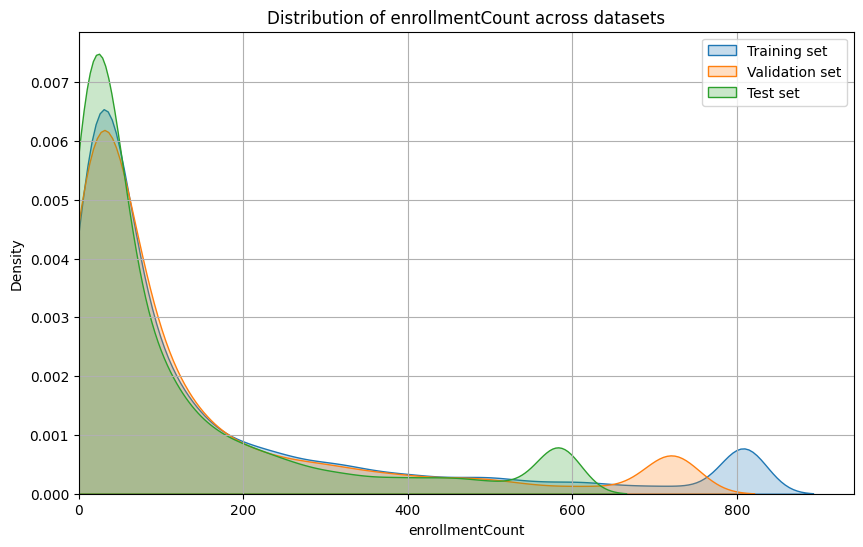

In [8]:
plot_three_cap_distributions(df_train=train_df, df_val=val_df, df_test=test_df, column_name='enrollmentCount', title='Distribution of enrollmentCount across datasets', cap_upper_extreme=True, upper_quantile=0.95, save_path='start.png')